In [7]:
#!/usr/bin/env python3
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path

# ==============================================================================
# Helper
# ==============================================================================
# ==============================================================================
# Configuration
# ==============================================================================

# SEARCH_CONFIGS = [
#     {
#         "base_path": "/home/boat/proxyISP/DGC-Net/proxydgc_eval_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32",
#         "pattern": re.compile(
#             r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1"
#         ),
#     },

#     {
#         "base_path": "/home/boat/proxyISP/DGC-Net/proxydgc_eval_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.005_gradac4",
#         "pattern": re.compile(
#             r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.005_gradac4_(\d+)_HpatchesV4.1"
#             # r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.005_gradac4_900_HpatchesV4.1"
#         ),
#     },

#     {
#         "base_path": "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_lowlight_maxstd0.1_csadampfac1.5",
#         "pattern": re.compile(
#             r"eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noiseaug0.6_(\d+)_HpatchesV4.1"
#         ),
#     },
# ]

SEARCH_CONFIGS = [
    {
        "name": "Proxy lr5e-4",
         "base_path": "/home/boat/proxyISP/DGC-Net/proxydgc_eval_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32",
        "pattern": re.compile(
            r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1"
        ),
         "checkpoint_dir": "/home/boat/proxyISP/DGC-Net/proxydgc_logs/FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32/checkpoints"
    },

    {
        "name": "Proxy lr5e-3",
         "base_path": "/home/boat/proxyISP/DGC-Net/proxydgc_eval_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.005_gradac4",
        "pattern": re.compile(
            r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.005_gradac4_(\d+)_HpatchesV4.1"
        ),
         "checkpoint_dir": "/home/boat/proxyISP/DGC-Net/proxydgc_logs/FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.005_gradac4/checkpoints"
    },

    {
        "name": "CMA-ES",
        "base_path": "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_lowlight_maxstd0.1_csadampfac1.5",
        "pattern": re.compile(
            r"eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noiseaug0.6_(\d+)_HpatchesV4.1"
        ),
         "checkpoint_dir": "/home/boat/proxyISP/DGC-Net/proxydgc_logs/CMAES_lowlight_maxstd0.1_CSA1.5_noiseaug0.6/cma_checkpoints"
    },
]

AEPE_FILENAME = "aepe.npy"
NUM_VIEWPOINTS = 5


def load_aepe(filepath):
    try:
        return np.load(filepath, allow_pickle=True)
    except Exception:
        with open(filepath, "r") as f:
            content = f.read()
        arr_str = re.findall(r"[\d\.eE\+\-]+", content)
        return np.array([float(x) for x in arr_str])


def estimate_sec_per_iter(eval_dirs):
    """
    Estimate seconds per iteration from checkpoint timestamps.
    """

    eval_dirs = sorted(eval_dirs, key=lambda x: x["iter"])

    sec_per_iter = []

    for prev, cur in zip(eval_dirs[:-1], eval_dirs[1:]):

        prev_ckpt = Path(prev["checkpoint_path"])
        cur_ckpt = Path(cur["checkpoint_path"])

        if not prev_ckpt.exists():
            continue

        if not cur_ckpt.exists():
            continue

        # mtime is preferred on Linux
        prev_time = prev_ckpt.stat().st_mtime
        cur_time = cur_ckpt.stat().st_mtime

        dt = cur_time - prev_time
        diter = cur["iter"] - prev["iter"]

        if diter <= 0:
            continue

        if dt <= 0:
            continue

        sec_per_iter.append(dt / diter)

    if len(sec_per_iter) == 0:
        return np.nan

    return float(np.median(sec_per_iter))
# ==============================================================================
# Step 1: Find matching evaluation directories
# ==============================================================================

eval_dirs = []

eval_dirs = []

for cfg in SEARCH_CONFIGS:

    base_path = cfg["base_path"]
    checkpoint_dir = cfg["checkpoint_dir"]
    pattern = cfg["pattern"]
    experiment = cfg.get("name", os.path.basename(base_path))

    if not os.path.isdir(base_path):
        print(f"[WARN] Missing base path: {base_path}")
        continue

    for name in os.listdir(base_path):

        full_path = os.path.join(base_path, name)

        if not os.path.isdir(full_path):
            continue

        m = pattern.match(name)

        if m is None:
            continue

        iteration = int(m.group(1))

        eval_dirs.append({
            "experiment": experiment,
            "iter": iteration,
            "dir_path": full_path,
            "checkpoint_path": os.path.join(
                checkpoint_dir,
                f"checkpoint_{iteration}.pkl"
            ),
        })

if len(eval_dirs) == 0:
    raise RuntimeError("No matching evaluation directories found.")

# ==============================================================================
# Step 2: Estimate iteration time for each experiment
# ==============================================================================

experiment_sec_per_iter = {}
experiment_first_iter = {}

for exp in sorted(set(d["experiment"] for d in eval_dirs)):

    dirs = [
        d
        for d in eval_dirs
        if d["experiment"] == exp
    ]

    dirs = sorted(dirs, key=lambda x: x["iter"])

    experiment_first_iter[exp] = dirs[0]["iter"]
    experiment_sec_per_iter[exp] = estimate_sec_per_iter(dirs)

    sec = experiment_sec_per_iter[exp]

    print(
        f"{exp:30s} "
        f"{sec:7.2f} sec/iter "
        f"({3600/sec:8.1f} iter/hour)"
    )

# ==============================================================================
# Step 3: Gather AEPE
# ==============================================================================

rows = []

for item in sorted(eval_dirs, key=lambda x: (x["experiment"], x["iter"])):

    aepe_path = os.path.join(item["dir_path"], AEPE_FILENAME)

    if not os.path.exists(aepe_path):
        print(f"[WARN] Missing {AEPE_FILENAME}: {item['dir_path']}")
        continue

    data = load_aepe(aepe_path)

    if len(data) != NUM_VIEWPOINTS:
        print(
            f"[WARN] Skipping {item['dir_path']}: "
            f"expected {NUM_VIEWPOINTS}, got {len(data)}"
        )
        continue

    sec_per_iter = experiment_sec_per_iter[item["experiment"]]

    elapsed_seconds = (
        (item["iter"] - experiment_first_iter[item["experiment"]])
        * sec_per_iter
    )

    rows.append({
        "experiment": item["experiment"],
        "iter": item["iter"],
        "elapsed_seconds": elapsed_seconds,
        "elapsed_minutes": elapsed_seconds / 60,
        "elapsed_hours": elapsed_seconds / 3600,
        "sec_per_iter": sec_per_iter,
        "dir_name": os.path.basename(item["dir_path"]),
        "avg_aepe": np.mean(data),
        **{
            f"v{i+1}": data[i]
            for i in range(NUM_VIEWPOINTS)
        }
    })

if len(rows) == 0:
    raise RuntimeError("No valid AEPE data found.")

# ==============================================================================
# Step 4: Build dataframe
# ==============================================================================

df = pd.DataFrame(rows)

df = df.sort_values(
    ["experiment", "iter"]
).reset_index(drop=True)

print(df.head())

CMA-ES                           11.87 sec/iter (   303.4 iter/hour)
Proxy lr5e-3                      0.53 sec/iter (  6776.1 iter/hour)
Proxy lr5e-4                      0.43 sec/iter (  8285.5 iter/hour)
  experiment  iter  elapsed_seconds  elapsed_minutes  elapsed_hours  \
0     CMA-ES     0         0.000000         0.000000       0.000000   
1     CMA-ES    50       593.348461         9.889141       0.164819   
2     CMA-ES   100      1186.696922        19.778282       0.329638   
3     CMA-ES   150      1780.045382        29.667423       0.494457   
4     CMA-ES   200      2373.393843        39.556564       0.659276   

   sec_per_iter                                           dir_name   avg_aepe  \
0     11.866969  eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noisea...  10.085815   
1     11.866969  eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noisea...  11.153173   
2     11.866969  eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noisea...  11.459163   
3     11.866969  eval_ll_CMAES_lowlight_ma

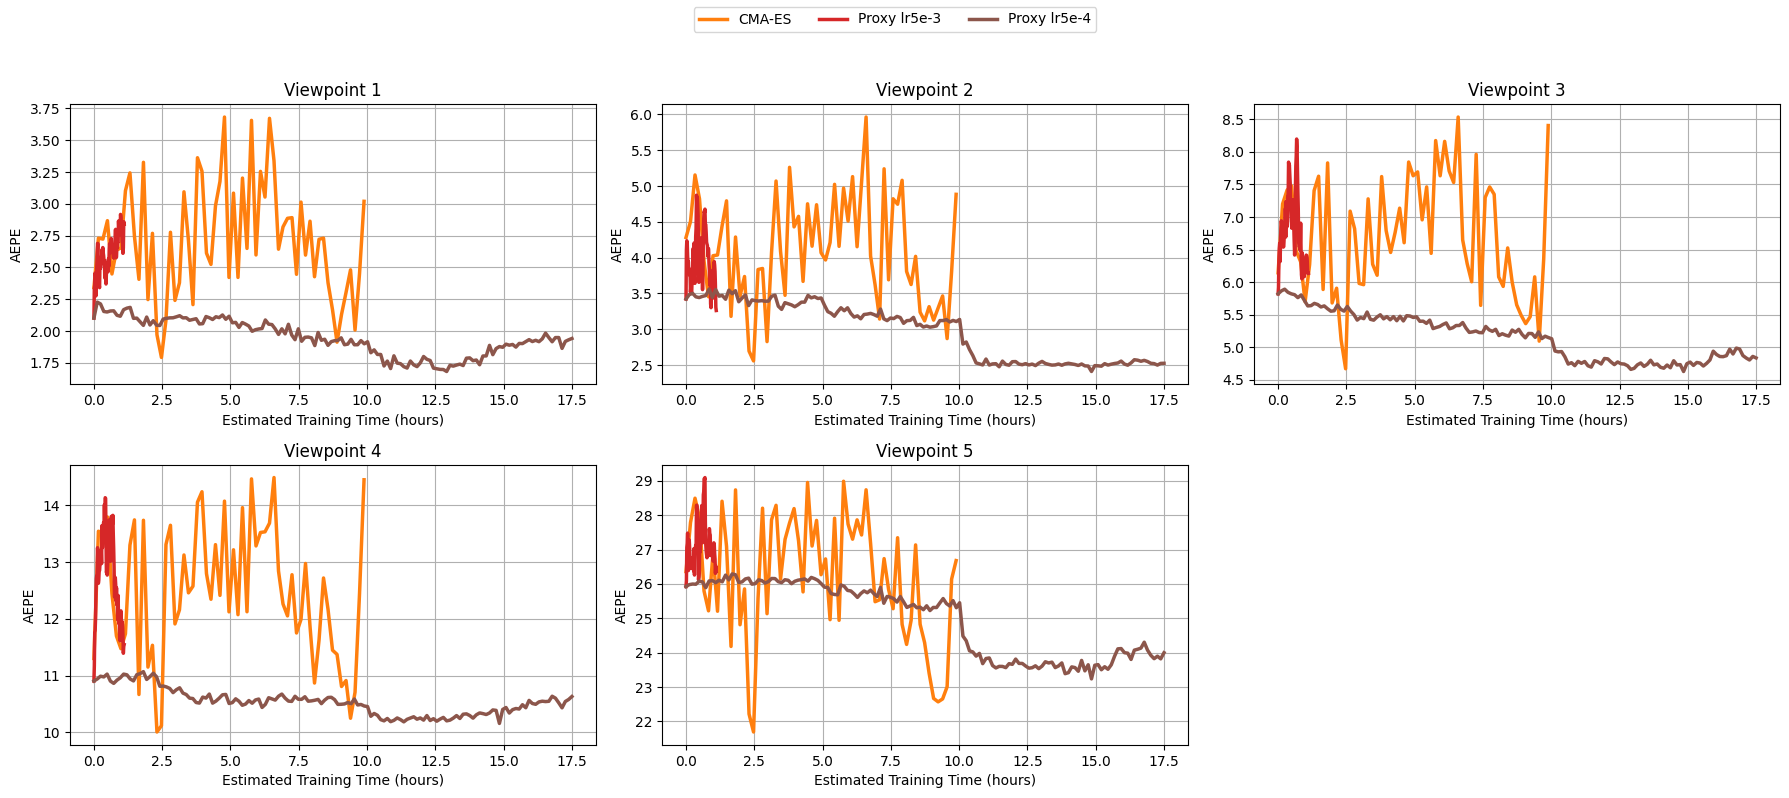

In [8]:
import matplotlib.pyplot as plt

alpha = 1.0

experiments = df["experiment"].unique()

nrows = 2
ncols = 3

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 8),
    sharey=False
)

axes = axes.flatten()

for i in range(NUM_VIEWPOINTS):
    ax = axes[i]
    col = f"v{i+1}"

    for exp in experiments:
        d = (
            df[df["experiment"] == exp]
            .sort_values("elapsed_hours")
        )

        ema = d[col].ewm(alpha=alpha).mean()

        # Raw curve
        ax.plot(
            d["elapsed_hours"],
            d[col],
            alpha=0.25,
            linewidth=1,
        )

        # EMA curve
        ax.plot(
            d["elapsed_hours"],
            ema,
            linewidth=2.5,
            label=exp,
        )

    ax.set_title(f"Viewpoint {i+1}")
    ax.set_xlabel("Estimated Training Time (hours)")
    ax.set_ylabel("AEPE")
    ax.grid(True)

# Hide unused subplot(s)
for j in range(NUM_VIEWPOINTS, len(axes)):
    axes[j].axis("off")

# Remove duplicate legend entries
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=min(4, len(by_label)),
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(
    "ema_overlay_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [23]:
#!/usr/bin/env python3
import os
import re
import numpy as np
import pandas as pd

# === Configuration ===
BASE_PATH = "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_lowlight_maxstd0.1_csadampfac1.5"  # Update if needed
# BASE_PATH = "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_sunlit_maxstd0.01_csadampfac10.0"
# BASE_PATH="/home/boat/proxyISP/DGC-Net/proxydgc_eval"
# BASE_PATH="/home/boat/proxyISP/DGC-Net/proxydgc_eval_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32"
DIR_PATTERN = re.compile(
    # r"eval_sl_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_sunlit_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1"
    # r"eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_(\d+)_HpatchesV4.1",
    # r"eval_*"
    r"eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noiseaug0.6_(\d+)_HpatchesV4.1"
    # r"eval_sl_CMAES_sunlit_maxstd0.01_CSA10.0_noiseaug0.6_(\d+)_HpatchesV4.1"
)
AEPE_FILENAME = "aepe.npy"
NUM_VIEWPOINTS = 5

def load_aepe(filepath):
    """Load AEPE values from .npy or raw file."""
    try:
        return np.load(filepath, allow_pickle=True)
    except Exception:
        with open(filepath, "r") as f:
            content = f.read()
        arr_str = re.findall(r"[\d\.eE\+\-]+", content)
        return np.array([float(x) for x in arr_str])

# === Step 1: Find matching evaluation directories ===
eval_dirs = []
for name in os.listdir(BASE_PATH):
    full_path = os.path.join(BASE_PATH, name)
    # print(full_path)
    if os.path.isdir(full_path):
        match = DIR_PATTERN.match(name)
        if match:
            iter_num = int(match.group(1))
            eval_dirs.append((iter_num, full_path))

if not eval_dirs:
    print("❌ No matching eval directories found.")
    
eval_dirs.sort(key=lambda x: x[0])

# === Step 2: Gather AEPE values ===
rows = []
for iter_num, dir_path in eval_dirs:
    aepe_path = os.path.join(dir_path, AEPE_FILENAME)
    if os.path.exists(aepe_path):
        data = load_aepe(aepe_path)
        if len(data) == NUM_VIEWPOINTS:
            rows.append({
                "iter": iter_num,
                "dir_name": os.path.basename(dir_path)[-20:],
                "avg_aepe": np.mean(data),
                **{f"v{i+1}": data[i] for i in range(NUM_VIEWPOINTS)}
            })
        else:
            print(f"[WARN] Skipping {dir_path}: expected {NUM_VIEWPOINTS} values, got {len(data)}")
    else:
        print(f"[WARN] {AEPE_FILENAME} not found in {dir_path}")

if not rows:
    print("❌ No valid AEPE data found.")

# === Step 3: Create and sort table ===
df = pd.DataFrame(rows)
df_sorted = df.sort_values(by="avg_aepe", ascending=True)

# === Step 4: Display results ===
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)  # Show all rows
print("\n🟢 Sorted AEPE results (ascending avg_aepe):")
df_sorted.to_string(index=False)
df_sorted




🟢 Sorted AEPE results (ascending avg_aepe):


,iter,dir_name,avg_aepe,v1,v2,v3,v4,v5
15,750,0.6_750_HpatchesV4.1,8.165636,1.792476,2.556679,4.671924,10.118430,21.688670
14,700,0.6_700_HpatchesV4.1,8.399468,1.971341,2.693415,5.112797,10.006982,22.212806
58,2900,.6_2900_HpatchesV4.1,8.737262,2.008061,2.868550,5.095470,10.707028,23.007199
55,2750,.6_2750_HpatchesV4.1,8.819302,2.130621,3.126481,5.363616,10.809177,22.666615
56,2800,.6_2800_HpatchesV4.1,8.909879,2.303280,3.295268,5.470830,10.913361,22.566653
57,2850,.6_2850_HpatchesV4.1,8.985425,2.481118,3.464522,6.080783,10.249295,22.651406
54,2700,.6_2700_HpatchesV4.1,9.098419,1.912362,3.314378,5.489571,11.375171,23.400612
10,500,0.6_500_HpatchesV4.1,9.264537,2.406643,3.179374,5.887820,10.668448,24.180402
53,2650,.6_2650_HpatchesV4.1,9.334766,2.166629,3.116207,5.651798,11.448032,24.291165
12,600,0.6_600_HpatchesV4.1,9.470405,2.247307,3.461069,5.680748,11.150496,24.812405
